In [1]:
! pip install kaggle
! pip install onnx
! pip install dagshub
! pip install mlflow
from google.colab import drive
drive.mount('/content/drive')
! mkdir ~/.kaggle
! cp /content/drive/MyDrive/ColabNotebooks/kaggle_API_credentials/kaggle.json ~/.kaggle/kaggle.json
! chmod 600 ~/.kaggle/kaggle.json
# ! kaggle competitions download -c walmart-recruiting-store-sales-forecasting
# ! unzip walmart-recruiting-store-sales-forecasting

Mounted at /content/drive


In [2]:
# ! unzip test.csv.zip
# ! unzip train.csv.zip
# ! unzip sampleSubmission.csv.zip
# ! unzip features.csv.zip

In [3]:
# ! rm -rf test.csv.zip
# ! rm -rf train.csv.zip
# ! rm -rf sampleSubmission.csv.zip
# ! rm -rf features.csv.zip

In [4]:
# 1. Clone your GitHub repo
!git clone https://github.com/arazm21/ML-final_project

# 2. Add the cloned repo (or specific folder) to sys.path
import sys
sys.path.insert(0, '/content/ML-final_project')


Cloning into 'ML-final_project'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 24 (delta 0), reused 21 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (24/24), 3.72 MiB | 10.99 MiB/s, done.


In [1]:
import torch # Main PyTorch Library
from torch import nn # Used for creating the layers and loss function
from torch.optim import Adam # Adam Optimizer
import torchvision.transforms as transforms # Transform function used to modify and preprocess all the images
from torch.utils.data import Dataset, DataLoader # Dataset class and DataLoader for creating the objects
from sklearn.preprocessing import LabelEncoder # Label Encoder to encode the classes from strings to numbers
import matplotlib.pyplot as plt # Used for visualizing the images and plotting the training progress
from PIL import Image # Used to read the images from the directory
import pandas as pd # Used to read/create dataframes (csv) and process tabular data
import numpy as np # preprocessing and numerical/mathematical operations
import os # Used to read the images path from the directory

device = "cuda" if torch.cuda.is_available() else "cpu" # detect the GPU if any, if not use CPU, change cuda to mps if you have a mac
print("Device available: ", device)

Device available:  cpu


In [69]:
# features_df = pd.read_csv('ML-final_project/data/features.csv/features.csv')
# sample_submission_df = pd.read_csv('ML-final_project/data/sampleSubmission.csv/sampleSubmission.csv')
# test_df = pd.read_csv('ML-final_project/data/test.csv/test.csv')
# train_df = pd.read_csv('ML-final_project/data/train.csv/train.csv')
# stores_df = pd.read_csv('ML-final_project/data/stores.csv')

features_df = pd.read_csv('data/features.csv/features.csv')
sample_submission_df = pd.read_csv('data/sampleSubmission.csv/sampleSubmission.csv')
test_df = pd.read_csv('data/test.csv/test.csv')
train_df = pd.read_csv('data/train.csv/train.csv')
stores_df = pd.read_csv('data/stores.csv')

In [4]:
display(train_df.head())

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [70]:
import pandas as pd

# Use the actual date range present in the data
all_dates = sorted(train_df['Date'].unique())

# Collect filled groups
filled_groups = []

# Process each Store/Dept group
for (store, dept), group in train_df.groupby(['Store', 'Dept']):
    group = group.set_index('Date')

    # Reindex to actual full dates in data
    reindexed = group.reindex(all_dates)
    reindexed.index.name = 'Date'

    # Fill identifying columns
    reindexed['Store'] = store
    reindexed['Dept'] = dept

    # Fill missing sales with 0
    reindexed['Weekly_Sales'] = reindexed['Weekly_Sales'].fillna(0)

    filled_groups.append(reindexed.reset_index())

# Concatenate full DataFrame
train_df_filled = pd.concat(filled_groups).sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)


In [67]:
train_df_filled.to_csv('temp/train_df_filled.csv', index=False)

In [71]:
train_df_filled = train_df_filled.drop(columns=['IsHoliday'], errors='ignore')

# Merge on 'Store' and 'Date'
train_merged = pd.merge(train_df_filled, features_df, on=['Store', 'Date'], how='left')
test_merged = pd.merge(test_df, features_df, on=['Store', 'Date'], how='left')
train_merged = pd.merge(train_merged, stores_df, on='Store', how='left')
test_merged = pd.merge(test_merged, stores_df, on='Store', how='left')

In [72]:
print(train_merged.columns)
print(train_merged.dtypes)
display(train_merged.head())


Index(['Date', 'Store', 'Dept', 'Weekly_Sales', 'Temperature', 'Fuel_Price',
       'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI',
       'Unemployment', 'IsHoliday', 'Type', 'Size'],
      dtype='object')
Date             object
Store             int64
Dept              int64
Weekly_Sales    float64
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float64
Unemployment    float64
IsHoliday          bool
Type             object
Size              int64
dtype: object


,Date,Store,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Type,Size
0,2010-02-05,1,1,24924.50,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,2010-02-12,1,1,46039.49,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,2010-02-19,1,1,41595.55,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,2010-02-26,1,1,19403.54,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,2010-03-05,1,1,21827.90,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315


## helper functions

### 1.feature engineering functions

In [ ]:


def add_holiday_lookahead(df):
    """
    Adds:
    - IsHolidayNextWeek: True if this week OR next week is a holiday.
    - IsHolidayIn2Weeks: True if this week OR next 2 weeks are holidays.
    """
    df = df.sort_values(by=['Store', 'Date']).copy()

    # current and future IsHoliday flags
    curr = df['IsHoliday'].astype(bool)
    next_1 = df.groupby('Store')['IsHoliday'].shift(-1).fillna(False).astype(bool)
    next_2 = df.groupby('Store')['IsHoliday'].shift(-2).fillna(False).astype(bool)

    df['IsHolidayNextWeek'] = (curr | next_1).astype(int)
    df['IsHolidayIn2Weeks'] = (curr | next_1 | next_2).astype(int)

    return df

def add_date_features(df):
    df['Date'] = pd.to_datetime(df['Date'])
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['WeekOfYear'] = df['Date'].dt.isocalendar().week
    # df['Day'] = df['Date'].dt.day
    # df['DayOfWeek'] = df['Date'].dt.weekday  # Monday=0, Sunday=6
    return df

# use this method for model which are not sequencial, i.e.xgboost
def drop_unneeded_columns(df, drop_date=True):
    """
    Drop or convert fields not usable by XGBoost directly.
    """
    df = df.copy()
    if drop_date and 'Date' in df.columns:
        df = df.drop(columns=['Date'])
    return df


## connecting wandb and dagshub

In [17]:
project_name = 'ML-final_project'
run_name = "test_run_1"
repo_owner = "arazm21"

In [18]:
import wandb
wandb.login()

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: arazm21 (arazm21-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [19]:
import dagshub
import mlflow
import mlflow.sklearn
dagshub.init(repo_owner=repo_owner, repo_name=project_name, mlflow=True)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=cd25537e-680f-44a0-9c17-2795377d273b&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=6081d3ccba1aaba46d9c80c9162f53fae7ff11afa8bf92adafb899c73f4b1b7a




Output()

Accessing as arazm21

Initialized MLflow to track repo "arazm21/ML-final_project"

Repository arazm21/ML-final_project initialized!

In [ ]:
# with wandb.init(project=project_name,
#                 config=hyperparameters,
#                 name = run_name):


## getting data ready

3


,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Type,Size
0,1,1,2010-02-05,24924.50,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,1,1,2010-02-12,46039.49,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,1,1,2010-02-19,41595.55,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,1,1,2010-02-26,19403.54,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,1,1,2010-03-05,21827.90,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315


## plots

### checking 3 departament/store combinations

143 2010-02-05 00:00:00 2012-10-26 00:00:00
143 2010-02-05 00:00:00 2012-10-26 00:00:00
143 2010-02-05 00:00:00 2012-10-26 00:00:00


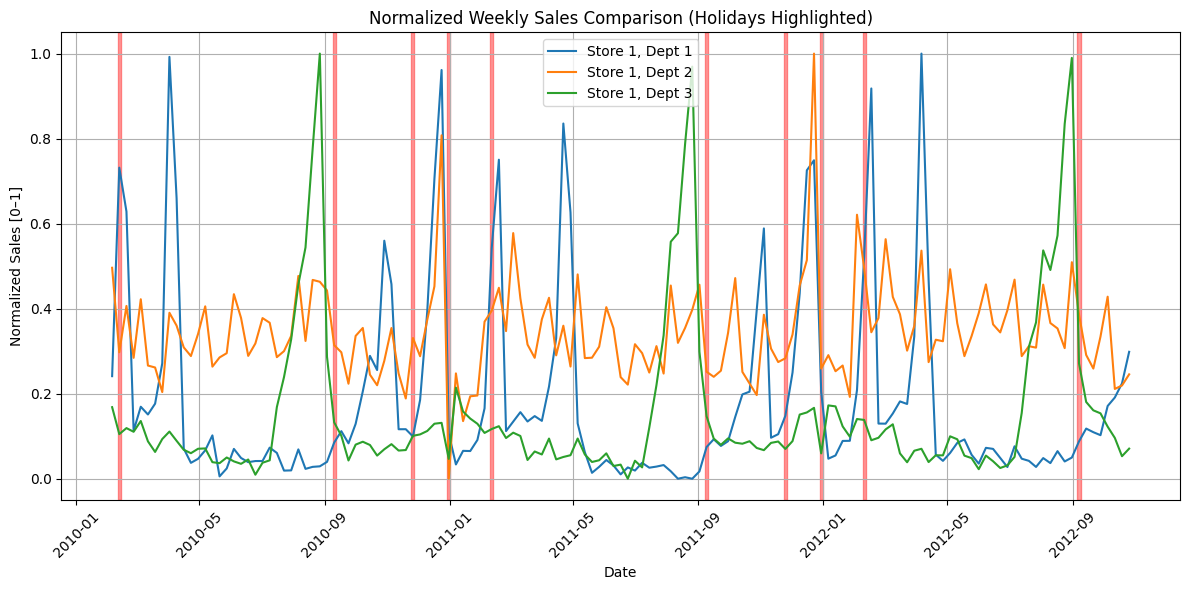

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
train_merged = train_merged.sort_values(['Store', 'Dept', 'Date'])

groups = [g for _, g in train_df.groupby(['Store', 'Dept']) if len(g) > 100]
selected = groups[:3]

selected_series = []
for (store, dept), group in train_merged.groupby(['Store', 'Dept']):
    if len(group) >= 100:
        selected_series.append((store, dept))
        if len(selected_series) == 3:
            break

# Plot normalized series
plt.figure(figsize=(12, 6))
ax = plt.gca()

for i, (store, dept) in enumerate(selected_series):
    series = train_merged[(train_merged['Store'] == store) & 
                          (train_merged['Dept'] == dept)].sort_values('Date').copy()

    series['Date'] = pd.to_datetime(series['Date'])  # 🛠️ Ensure datetime
    print(len(series), series["Date"].iloc[0], series["Date"].iloc[-1])

    # Min-Max normalization
    normalized_sales = (series['Weekly_Sales'] - series['Weekly_Sales'].min()) / \
                       (series['Weekly_Sales'].max() - series['Weekly_Sales'].min())
    
    plt.plot(series['Date'], normalized_sales, label=f"Store {store}, Dept {dept}")

    # Highlight holiday weeks
    holidays = series[series['IsHoliday'] == True]['Date']
    for holiday_date in holidays:
        ax.axvspan(holiday_date - pd.Timedelta(days=1.5),
                   holiday_date + pd.Timedelta(days=1.5),
                   color='red', alpha=0.15)

plt.title('Normalized Weekly Sales Comparison (Holidays Highlighted)')
plt.xlabel('Date')
plt.ylabel('Normalized Sales [0–1]')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [39]:
# Expected sales range differences:
print(train_merged.groupby(['Store','Dept'])['Weekly_Sales'].agg([np.mean, np.std]))

                    mean           std
Store Dept                            
1     1     22513.322937   9854.349032
      2     46102.090420   3440.673222
      3     13150.478042   8708.978853
      4     36964.154476   2930.698313
      5     24257.941119  11330.286495
...                  ...           ...
45    94     3690.272090   1852.287364
      95    52896.166643   5117.961708
      96        2.970000      0.042426
      97     6466.961888    659.739542
      98      561.239037    371.286705

[3331 rows x 2 columns]


C:\Users\alex\AppData\Local\Temp\ipykernel_32772\3343407106.py:2: FutureWarning: The provided callable <function mean at 0x0000021C642AF420> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  print(train_merged.groupby(['Store','Dept'])['Weekly_Sales'].agg([np.mean, np.std]))
C:\Users\alex\AppData\Local\Temp\ipykernel_32772\3343407106.py:2: FutureWarning: The provided callable <function std at 0x0000021C642AF560> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  print(train_merged.groupby(['Store','Dept'])['Weekly_Sales'].agg([np.mean, np.std]))


### trends across all stores/departaments

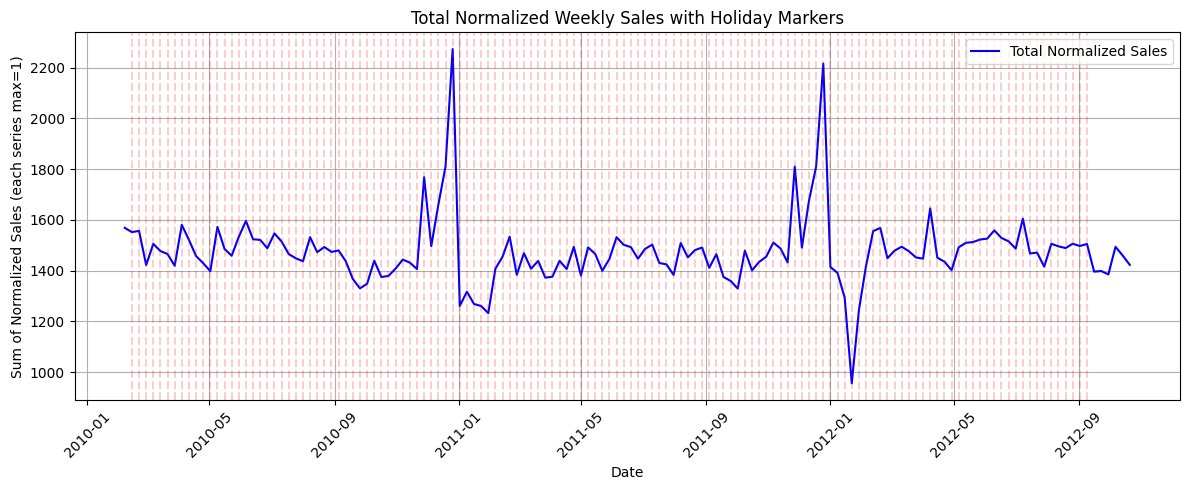

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure Date is datetime
train_merged['Date'] = pd.to_datetime(train_merged['Date'])

# Define common weekly index
common_index = pd.date_range(start=train_merged['Date'].min(),
                             end=train_merged['Date'].max(),
                             freq='W')

# Step 1: Normalize each Store–Dept combo (max = 1)
normalized_series_list = []

for (store, dept), group in train_merged.groupby(['Store', 'Dept']):
    group = group.set_index('Date').sort_index()
    weekly_sales = group['Weekly_Sales'].resample('W').sum()

    max_sales = weekly_sales.max()
    if pd.isna(max_sales) or max_sales == 0:
        continue

    normalized = weekly_sales / max_sales
    normalized = normalized.reindex(common_index).interpolate(limit_direction='both')
    normalized_series_list.append(normalized)

# Step 2: Add all normalized series together
normalized_df = pd.DataFrame(normalized_series_list).T
total_normalized_sales = normalized_df.sum(axis=1)

# Step 3: Get unique holiday weeks (from any store/dept)
holiday_weeks = (
    train_merged[train_merged['IsHoliday'] == True]
    .set_index('Date')
    .resample('W').max()
    .index
)

# Step 4: Plot with holiday lines
plt.figure(figsize=(12, 5))
plt.plot(common_index, total_normalized_sales, color='blue', label='Total Normalized Sales')

# Draw vertical lines for holidays
for date in holiday_weeks:
    plt.axvline(date, color='red', linestyle='--', alpha=0.2)

plt.title('Total Normalized Weekly Sales with Holiday Markers')
plt.xlabel('Date')
plt.ylabel('Sum of Normalized Sales (each series max=1)')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


### each store agains each other (summing departaments)

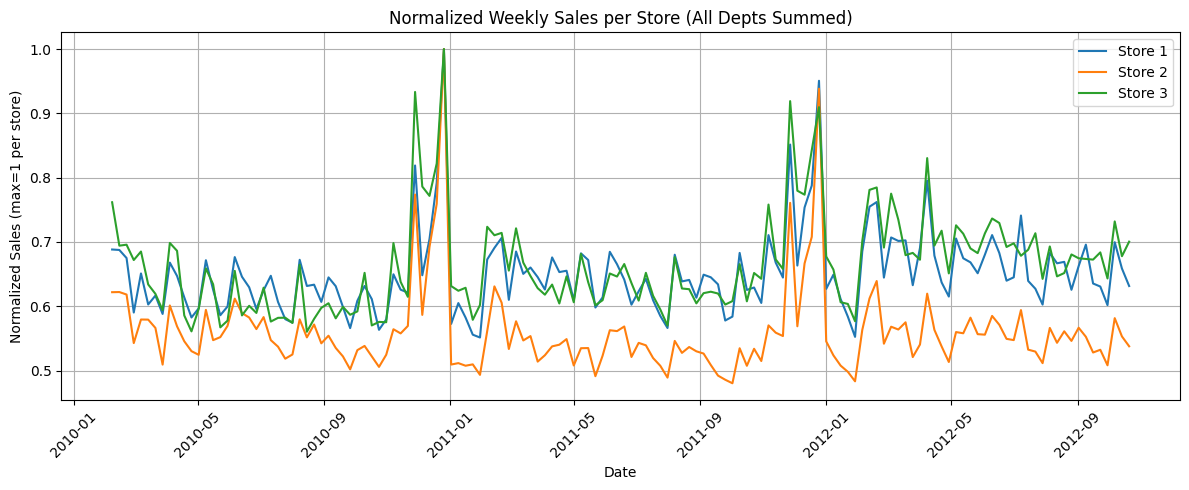

In [49]:
import matplotlib.pyplot as plt

# Set weekly index range
weekly_index = pd.date_range(train_merged['Date'].min(), train_merged['Date'].max(), freq='W')

# Step 1: Group by Store (sum over Depts)
store_series_list = []
store_ids = []

for store, group in train_merged.groupby('Store'):
    group = group.set_index('Date').sort_index()
    weekly_sales = group['Weekly_Sales'].resample('W').sum()

    max_sales = weekly_sales.max()
    if pd.isna(max_sales) or max_sales == 0:
        continue

    normalized = weekly_sales / max_sales
    normalized = normalized.reindex(weekly_index).interpolate(limit_direction='both')
    
    store_series_list.append(normalized)
    store_ids.append(store)

    if len(store_series_list) == 3:
        break

# Plot 3 stores
plt.figure(figsize=(12, 5))
for series, store_id in zip(store_series_list, store_ids):
    plt.plot(weekly_index, series, label=f"Store {store_id}")

plt.title("Normalized Weekly Sales per Store (All Depts Summed)")
plt.xlabel("Date")
plt.ylabel("Normalized Sales (max=1 per store)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### each departament agains each other (summing all stores)

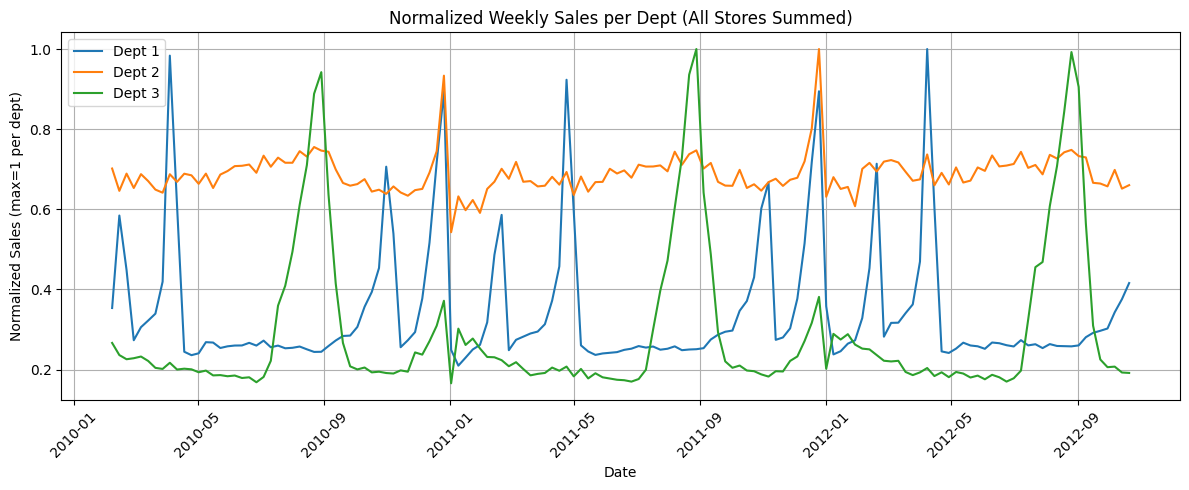

In [50]:
# Step 2: Group by Dept (sum over Stores)
dept_series_list = []
dept_ids = []

for dept, group in train_merged.groupby('Dept'):
    group = group.set_index('Date').sort_index()
    weekly_sales = group['Weekly_Sales'].resample('W').sum()

    max_sales = weekly_sales.max()
    if pd.isna(max_sales) or max_sales == 0:
        continue

    normalized = weekly_sales / max_sales
    normalized = normalized.reindex(weekly_index).interpolate(limit_direction='both')
    
    dept_series_list.append(normalized)
    dept_ids.append(dept)

    if len(dept_series_list) == 3:
        break

# Plot 3 depts
plt.figure(figsize=(12, 5))
for series, dept_id in zip(dept_series_list, dept_ids):
    plt.plot(weekly_index, series, label=f"Dept {dept_id}")

plt.title("Normalized Weekly Sales per Dept (All Stores Summed)")
plt.xlabel("Date")
plt.ylabel("Normalized Sales (max=1 per dept)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# actual train start

## methods

In [8]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd
import numpy as np

### date adder

In [9]:
class StoreDeptCompleter(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.full_index = None
        self.holiday_map = None

    def fit(self, X, y=None):
        stores = X['Store'].unique()
        depts = X['Dept'].unique()
        dates = pd.to_datetime(X['Date'].unique())

        # Create full MultiIndex of all combinations
        full_index = pd.MultiIndex.from_product(
            [stores, depts, dates], names=['Store', 'Dept', 'Date']
        )
        self.full_index = full_index

        # Build IsHoliday map
        self.holiday_map = X.groupby('Date')['IsHoliday'].first().to_dict()
        return self

    def transform(self, X):
        X = X.copy()
        X['Date'] = pd.to_datetime(X['Date'])

        # Set index and reindex to full grid
        X = X.set_index(['Store', 'Dept', 'Date']).sort_index()
        X = X.reindex(self.full_index)

        # Restore index columns
        X = X.reset_index()

        # Fill IsHoliday using known map
        X['IsHoliday'] = X['Date'].map(self.holiday_map).fillna(False).astype(bool)

        return X


### feature engineering methods

In [61]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class DateFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, date_column='Date'):
        self.date_column = date_column
        
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        X = X.copy()
        dates = pd.to_datetime(X[self.date_column])
        X['month'] = dates.dt.month
        X['week'] = dates.dt.isocalendar().week
        X['day_of_week'] = dates.dt.dayofweek
        return X
   
# class StoreDeptInteractor(BaseEstimator, TransformerMixin):
#     def fit(self, X, y=None):
#         return self
#         
#     def transform(self, X):
#         X = X.copy()
#         X['store_dept'] = (
#             X['Store'].astype('str') + '_' + X['Dept'].astype('str'))
#         return X
#     
# from sklearn.model_selection import TimeSeriesSplit
# from category_encoders import TargetEncoder
# 
# class TimeAwareTargetEncoder(BaseEstimator, TransformerMixin):
#     def __init__(self, cols, n_splits=5):
#         self.cols = cols
#         self.n_splits = n_splits
#         self.encoders = {}
#         
#     def fit(self, X, y):
#         X = X.copy()
#         tscv = TimeSeriesSplit(n_splits=self.n_splits)
#         
#         # Initialize with global mean
#         self.global_mean = y.mean()
#         
#         for train_idx, _ in tscv.split(X):
#             X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
#             for col in self.cols:
#                 encoder = TargetEncoder()
#                 encoder.fit(X_train[[col]], y_train)
#                 self.encoders.setdefault(col, []).append(encoder)
#         return self
#         
#     def transform(self, X):
#         X = X.copy()
#         for col in self.cols:
#             col_avg = X[col].map(
#                 X.groupby(col)['__target__'].mean()
#             ).fillna(self.global_mean)
#             
#             if col in self.encoders:
#                 # Average predictions from different time folds
#                 encodings = [enc.transform(X[[col]]) for enc in self.encoders[col]]
#                 X[col] = sum(enc[col] for enc in encodings) / len(encodings)
#             else:
#                 X[col] = col_avg
#         return X.drop(columns=['__target__'])
#     
class LagFeatureGenerator(BaseEstimator, TransformerMixin):
    def __init__(self, lags=[1, 2, 3, 52, 53], fill_strategy='flag'):
        self.lags = lags
        self.fill_strategy = fill_strategy  # 'rolling', 'zero', or 'flag'

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy().sort_values(['Store', 'Dept', 'Date'])
        for lag in self.lags:
            X[f'lag_{lag}'] = X.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(lag)
            
            if self.fill_strategy == 'rolling':
                # Fill with expanding mean (past data only)
                X[f'lag_{lag}'] = (X.groupby(['Store', 'Dept'])[f'lag_{lag}'].transform(lambda x: x.fillna(x.expanding().mean())))
            elif self.fill_strategy == 'flag':
                X[f'lag_{lag}_missing'] = X[f'lag_{lag}'].isna().astype(int)
                X[f'lag_{lag}'] = X[f'lag_{lag}'].fillna(0)
            else:  # 'zero'
                X[f'lag_{lag}'] = X[f'lag_{lag}'].fillna(0)
                
        return X
    
class TimeFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, datetime_col):
        self.datetime_col = datetime_col

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X['month'] = X[self.datetime_col].dt.month
        # X['dayofweek'] = X[self.datetime_col].dt.dayofweek
        # X['hour'] = X[self.datetime_col].dt.hour
        # return X.drop(columns=[self.datetime_col])
        return X

class LagFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, target_col, lags=[52,53,]):
        self.target_col = target_col
        self.lags = lags

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for lag in self.lags:
            X[f'{self.target_col}_lag_{lag}'] = X[self.target_col].shift(lag)
        return X


class RollingFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, target_col, windows=[3, 7]):
        self.target_col = target_col
        self.windows = windows

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for w in self.windows:
            X[f'{self.target_col}_rollmean_{w}'] = X[self.target_col].rolling(w).mean()
            X[f'{self.target_col}_rollstd_{w}'] = X[self.target_col].rolling(w).std()
        return X


class HolidayFlags(BaseEstimator, TransformerMixin):
    def __init__(self, date_col='Date'):
        self.date_col = date_col
        # Exact holiday dates from dataset (weekly sale dates)
        self.holiday_dates = {
            'SuperBowl': ["2010-02-12","2011-02-11","2012-02-10","2013-02-08"],
            'LaborDay':  ["2010-09-10","2011-09-09","2012-09-07","2013-09-06"],
            'Thanksgiving': ["2010-11-26","2011-11-25","2012-11-23","2013-11-29"],
            'Christmas': ["2010-12-31","2011-12-30","2012-12-28","2013-12-27"]
        }

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X[self.date_col] = pd.to_datetime(X[self.date_col])
        for name, dates in self.holiday_dates.items():
            X[f'Is{name}'] = X[self.date_col].dt.strftime('%Y-%m-%d').isin(dates).astype(int)
        return X
    
class UpcomingHolidayFlags(BaseEstimator, TransformerMixin):
    def __init__(self, date_col='Date', horizon_weeks=[1, 2, 3]):
        self.date_col = date_col
        self.horizon_weeks = horizon_weeks
        self.holiday_dates = None

    def fit(self, X, y=None):
        self.holiday_dates = set(pd.to_datetime(X.loc[X['IsHoliday'], self.date_col]))
        return self

    def transform(self, X):
        X = X.copy()
        X[self.date_col] = pd.to_datetime(X[self.date_col])
    
        for weeks in self.horizon_weeks:
            colname = f'HolidayIn{weeks}Weeks'
    
            X[colname] = X[self.date_col].apply(
                lambda d: int(any(
                    (d + pd.Timedelta(days=i)) in self.holiday_dates
                    for i in range(1, weeks * 7 + 1)
                ))
            )
    
        return X

    
class MergeExternalFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, features_df, stores_df):
        self.features_df = features_df.copy()
        self.stores_df = stores_df.copy()
        self.features_df = self.features_df.drop(columns=['IsHoliday'], errors='ignore')


        # Ensure features_df Date is datetime
        self.features_df['Date'] = pd.to_datetime(self.features_df['Date'], errors='coerce')

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X['Date'] = pd.to_datetime(X['Date'], errors='coerce')

        # Merge features.csv
        X = pd.merge(X, self.features_df, on=['Store', 'Date'], how='left')

        # Merge stores.csv (Store is already numeric so no need for conversion)
        X = pd.merge(X, self.stores_df, on='Store', how='left')

        return X



### missing date imputing methods

In [48]:
class TimeSeriesImputer(BaseEstimator, TransformerMixin):
    def __init__(self, method='ffill'):
        self.method = method

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.fillna(method=self.method)


from sklearn.linear_model import LinearRegression

class DepartmentWeeklyImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.weekly_dept_avg = None  # avg weekly sales per dept per week
        self.scaling_factors = {}    # (Store, Dept): scale

    def fit(self, X, y=None):
        X = X.copy()
        X['Date'] = pd.to_datetime(X['Date'])
        X['Week'] = X['Date'].dt.isocalendar().week

        # Pivot: count non-null weekly sales per store-dept
        counts = X.groupby(['Store', 'Dept'])['Weekly_Sales'].count().reset_index()
        full_weeks = X['Date'].nunique()

        # Only use fully complete store-dept combos to compute the weekly average
        complete_combos = counts[counts['Weekly_Sales'] == full_weeks][['Store', 'Dept']]
        merged = X.merge(complete_combos, on=['Store', 'Dept'])
        self.weekly_dept_avg = (
            merged.groupby(['Dept', 'Week'])['Weekly_Sales'].mean().rename('Avg_Sales')
        )

        # Fit scaling factor for each incomplete store-dept
        incomplete_combos = counts[counts['Weekly_Sales'] < full_weeks][['Store', 'Dept']]
        for _, row in incomplete_combos.iterrows():
            store, dept = row['Store'], row['Dept']
            sub = X[(X['Store'] == store) & (X['Dept'] == dept)].copy()
            sub = sub[sub['Weekly_Sales'].notna()]
            sub['Week'] = sub['Date'].dt.isocalendar().week
        
            # Fix: reset and filter by dept instead of indexing directly
            dept_avg_df = self.weekly_dept_avg.reset_index()
            dept_avg_filtered = dept_avg_df[dept_avg_df['Dept'] == dept]
            sub = sub.merge(dept_avg_filtered, on='Week', how='left')
        
            if not sub.empty and sub['Avg_Sales'].notna().any():
                model = LinearRegression(fit_intercept=False)
                model.fit(sub[['Avg_Sales']], sub['Weekly_Sales'])
                self.scaling_factors[(store, dept)] = model.coef_[0]        
        return self

    def transform(self, X):
        X = X.copy()
        X['Date'] = pd.to_datetime(X['Date'])
        X['Week'] = X['Date'].dt.isocalendar().week

        def impute(row):
            if pd.notna(row['Weekly_Sales']):
                return row['Weekly_Sales']
            key = (row['Store'], row['Dept'])
            base = self.weekly_dept_avg.get((row['Dept'], row['Week']), np.nan)
            scale = self.scaling_factors.get(key, np.nan)
            return base * scale if pd.notna(base) and pd.notna(scale) else np.nan

        X['Weekly_Sales'] = X.apply(impute, axis=1)
        return X.drop(columns='Week')
#     
# class FillDeptDateMissingSales(BaseEstimator, TransformerMixin):
#     def __init__(self, sales_col='Weekly_Sales'):
#         self.sales_col = sales_col
# 
#     def fit(self, X, y=None):
#         return self  # nothing to learn
# 
#     def transform(self, X):
#         X = X.copy()
# 
#         def fill_group(group):
#             sales = group[self.sales_col]
#             if sales.isnull().all():
#                 group[self.sales_col] = 0
#             else:
#                 group[self.sales_col] = sales.fillna(sales.mean())
#             return group
# 
#         # This avoids the warning by ensuring you're not modifying the grouping columns
#         grouped = X.groupby(['Date', 'Dept'], group_keys=False)
#         return grouped.apply(fill_group, include_groups=False)

class FillDeptDateMissingSales(BaseEstimator, TransformerMixin):
    def __init__(self, sales_col='Weekly_Sales'):
        self.sales_col = sales_col

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        def fill_group(group):
            sales = group[self.sales_col]
            if sales.isnull().all():
                group[self.sales_col] = 0
            else:
                group[self.sales_col] = sales.fillna(sales.mean())
            return group

        grouped = X.groupby(['Date', 'Dept'], group_keys=False)
        return grouped.apply(fill_group)

class AddMissingStoreDeptData(BaseEstimator, TransformerMixin):
    def __init__(self, test_df):
        self.test_df = test_df

    def fit(self, X, y=None):
        return self  # stateless

    def transform(self, X):
        train_df = X.copy()

        # Get existing and required store/dept combinations
        train_combos = set(train_df[['Store', 'Dept']].drop_duplicates().apply(tuple, axis=1))
        test_combos = set(self.test_df[['Store', 'Dept']].drop_duplicates().apply(tuple, axis=1))

        missing_combos = test_combos - train_combos
        print("missing_combos:", missing_combos)
        if not missing_combos:
            return train_df  # No need to do anything
    
        full_dates = train_df['Date'].drop_duplicates().sort_values()
        result_df = train_df.copy()

        for store, dept in missing_combos:
            # Average Dept 1 sales for this store
            dept1_this_store = train_df[(train_df['Store'] == store) & (train_df['Dept'] == 1)]
            if dept1_this_store.empty:
                continue  # No scaling factor possible

            store_dept1_avg = dept1_this_store['Weekly_Sales'].mean()

            # Get average of Dept 1 across stores that also have the target dept
            stores_with_dept = train_df[train_df['Dept'] == dept]['Store'].unique()
            dept1_those_stores = train_df[
                (train_df['Dept'] == 1) & (train_df['Store'].isin(stores_with_dept))
            ]

            if dept1_those_stores.empty:
                continue  # Still no scaling possible

            overall_dept1_avg = dept1_those_stores['Weekly_Sales'].mean()

            # Compute multiplier
            multiplier = store_dept1_avg / overall_dept1_avg if overall_dept1_avg != 0 else 1.0

            # Get average sales for this department across all other stores
            avg_dept_values = train_df[train_df['Dept'] == dept].groupby('Date')['Weekly_Sales'].mean()

            # Create new rows
            new_rows = []
            for date in full_dates:
                row = {
                    'Store': store,
                    'Dept': dept,
                    'Date': date,
                    'Weekly_Sales': avg_dept_values.get(date, 0) * multiplier
                }

                # Add the rest of the columns as NaNs (will be imputed later)
                for col in train_df.columns:
                    if col not in row:
                        row[col] = np.nan

                new_rows.append(row)

            new_df = pd.DataFrame(new_rows)
            result_df = pd.concat([result_df, new_df], ignore_index=True)

        return result_df
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import numpy as np

class CustomFillerEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, custom_fill: dict = None):
        self.custom_fill = custom_fill if custom_fill is not None else {}
        self.mean_values_ = {}
        self.ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
        self.type_columns_ = None

    def fit(self, X, y=None):
        X = X.copy()

        # Columns to handle explicitly
        self.markdown_cols = [col for col in X.columns if col.startswith("MarkDown")]
        self.mean_fill_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size']
        self.bool_cols = ['IsHoliday']
        self.type_col = 'Type'

        # Compute means for mean_fill_cols
        for col in self.mean_fill_cols:
            if col in X.columns:
                self.mean_values_[col] = X[col].mean()

        # Fit one-hot encoder for 'Type'
        if self.type_col in X.columns:
            self.ohe.fit(X[[self.type_col]])
            self.type_columns_ = self.ohe.get_feature_names_out([self.type_col])

        return self

    def transform(self, X):
        X = X.copy()

        # Fill markdowns with 0
        for col in self.markdown_cols:
            if col in X.columns:
                X[col] = X[col].fillna(0)

        # Fill continuous with mean
        for col in self.mean_fill_cols:
            if col in X.columns:
                X[col] = X[col].fillna(self.mean_values_.get(col, 0))

        # Fill boolean with 0 (or as specified)
        for col in self.bool_cols:
            if col in X.columns:
                X[col] = X[col].fillna(self.custom_fill.get(col, 0)).astype(int)

        # One-hot encode 'Type'
        if self.type_col in X.columns:
            type_encoded = self.ohe.transform(X[[self.type_col]])
            type_df = pd.DataFrame(type_encoded, columns=self.type_columns_, index=X.index)
            X = X.drop(columns=[self.type_col])
            X = pd.concat([X, type_df], axis=1)

        # Apply default fill (0) to all other missing columns
        for col in X.columns:
            if X[col].isnull().any():
                X[col] = X[col].fillna(self.custom_fill.get(col, 0))

        return X
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
class OneHotEncoderTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, categorical_columns, drop_original=False):
        self.categorical_columns = categorical_columns
        self.drop_original = drop_original
        self.encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

    def fit(self, X, y=None):
        self.encoder.fit(X[self.categorical_columns])
        return self

    def transform(self, X):
        X = X.copy()
        ohe_array = self.encoder.transform(X[self.categorical_columns])
        ohe_cols = self.encoder.get_feature_names_out(self.categorical_columns)
        ohe_df = pd.DataFrame(ohe_array, columns=ohe_cols, index=X.index)

        if self.drop_original:
            X = X.drop(columns=self.categorical_columns)

        return pd.concat([X, ohe_df], axis=1)
    

from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class LagFeatureAdder(BaseEstimator, TransformerMixin):
    def __init__(self, train_df, lags=[52,53], date_col='Date'):
        self.train_df = train_df.copy()
        self.lags = lags
        self.date_col = date_col

        # Make sure Date column is datetime
        self.train_df[self.date_col] = pd.to_datetime(self.train_df[self.date_col])
        self.train_df.set_index(['Store', 'Dept', self.date_col], inplace=True)

    def fit(self, X, y=None):
        return self  # No fitting necessary

    def transform(self, X):
        X = X.copy()
        X[self.date_col] = pd.to_datetime(X[self.date_col])
        
        for lag in self.lags:
            lag_col = f"lag_{lag}"
            X[lag_col] = X.apply(lambda row: self._get_lag_value(row, lag), axis=1)
        
        return X

    def _get_lag_value(self, row, lag):
        lag_date = row[self.date_col] - pd.Timedelta(weeks=lag)
        key = (row['Store'], row['Dept'], lag_date)
        try:
            return self.train_df.loc[key]['Weekly_Sales']
        except KeyError:
            return float('nan')  # If missing, return NaN


## pipeline

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline


early_preprocessing_pipeline = Pipeline(steps=[
    ('store_dept_completion', StoreDeptCompleter()),
    ('merge_features_and_stores', MergeExternalFeatures(
        features_df=pd.read_csv('data/features.csv/features.csv'),
        stores_df=pd.read_csv('data/stores.csv')
    )),
])
feature_engineering = Pipeline(steps=[
    ('holiday_flags', HolidayFlags(date_col='Date')),
    ('time_features', TimeFeatures(datetime_col='Date')),
    # ('lag_features', LagFeatures(target_col='Weekly_Sales', lags=[1,2,3])),
    # ('rolling_features', RollingFeatures(target_col='Weekly_Sales', windows=[3,7])),
    ('upcoming_holiday_flags', UpcomingHolidayFlags()),
])

imputer_pipeline = Pipeline(steps=[
    ('imputer', DepartmentWeeklyImputer()),
    ('remaining_imputer',FillDeptDateMissingSales()),
    ('missing_combos_filler',AddMissingStoreDeptData(test_df=test_df))
])

feature_engineering_2 = Pipeline(steps=[
    # ('holiday_flags', HolidayFlags(date_col='Date')),
    # ('time_features', TimeFeatures(datetime_col='Date')),
    ('lag_features', LagFeatures(target_col='Weekly_Sales', lags=[1,2,3])),
    ('rolling_features', RollingFeatures(target_col='Weekly_Sales', windows=[3,7])),
    # ('upcoming_holiday_flags', UpcomingHolidayFlags()),
])

modeling_pipeline = Pipeline(steps=[
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])


## download data

In [31]:
sample_submission_df = pd.read_csv('data/sampleSubmission.csv/sampleSubmission.csv')
test_df = pd.read_csv('data/test.csv/test.csv')
train_df = pd.read_csv('data/train.csv/train.csv')
train_df['Date'] = pd.to_datetime(train_df['Date'])
test_df['Date'] = pd.to_datetime(test_df['Date'])

In [25]:
print(train_df.dtypes)

Store                    int64
Dept                     int64
Date            datetime64[ns]
Weekly_Sales           float64
IsHoliday                 bool
dtype: object


## fit/transform

In [6]:
train_fixed = early_preprocessing_pipeline.fit_transform(train_df)
print(train_df.shape)
print(train_fixed.shape)
train_fixed_df = pd.DataFrame(train_fixed)
train_fixed_df.to_csv('temp/early_preprocessing.csv', index=False)

NameError: name 'train_df' is not defined

In [7]:
print(train_df.shape)
print(train_fixed.shape)

NameError: name 'train_df' is not defined

In [8]:
train_new_features = feature_engineering.fit_transform(train_fixed)
display(train_new_features.head(10))

NameError: name 'train_fixed' is not defined

In [9]:
train_imputed = imputer_pipeline.fit_transform(train_new_features)

NameError: name 'imputer_pipeline' is not defined

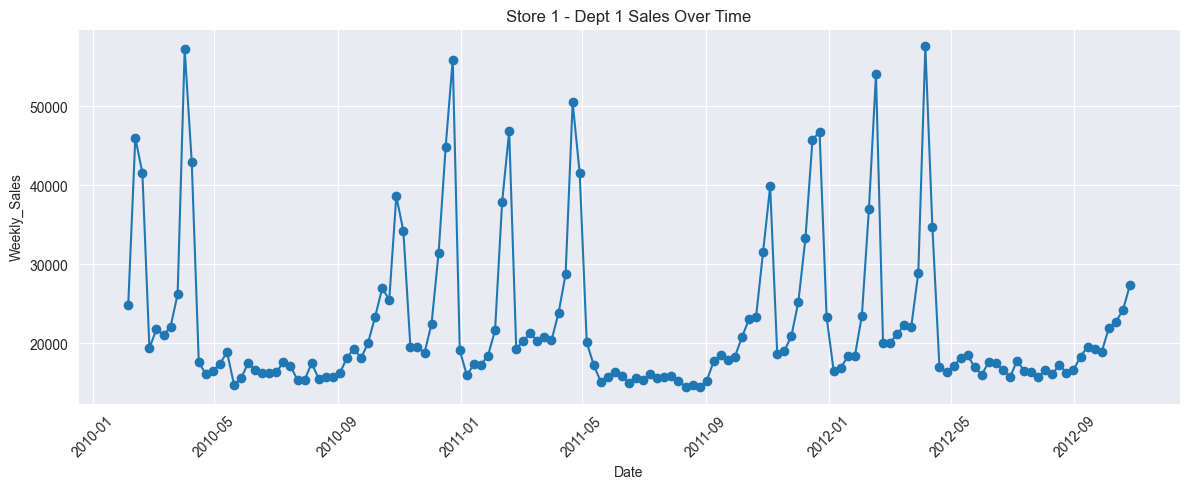

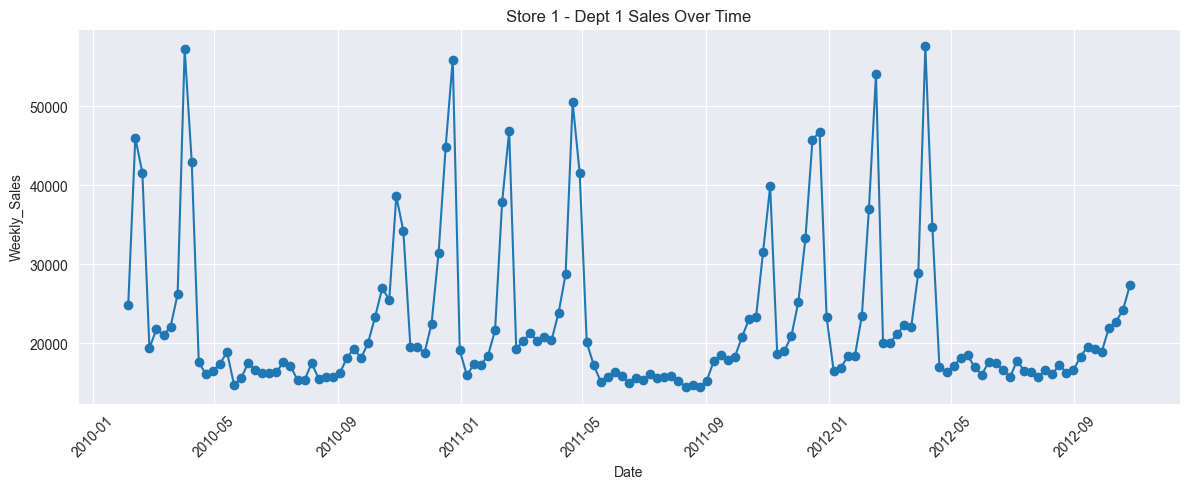

In [130]:
import matplotlib.pyplot as plt

def plot_store_dept_sales(df, store, dept, date_col='Date', target_col='Weekly_Sales'):
    """
    Plot sales for a specific store/dept combo.

    Parameters:
        df (pd.DataFrame): The dataframe containing sales data.
        store (int): The store number to filter.
        dept (int): The department number to filter.
        date_col (str): Name of the date column.
        target_col (str): Name of the target column (e.g., Weekly_Sales).
    """
    # Filter
    subset = df[(df['Store'] == store) & (df['Dept'] == dept)]

    if subset.empty:
        print(f"No data for Store {store}, Dept {dept}")
        return

    # Sort by date for correct plotting
    subset = subset.sort_values(date_col)

    # Plot
    plt.figure(figsize=(12, 5))
    plt.plot(subset[date_col], subset[target_col], marker='o', linestyle='-')
    plt.title(f"Store {store} - Dept {dept} Sales Over Time")
    plt.xlabel("Date")
    plt.ylabel(target_col)
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
plot_store_dept_sales(train_new_features, store=1, dept=1)
plot_store_dept_sales(train_imputed, store=1, dept=1)


In [94]:
print(train_new_features['Weekly_Sales'].isna().sum())
print(train_imputed['Weekly_Sales'].isna().sum())
train_imputed.to_csv('temp/train_imputed.csv', index=False)

99665
0


## connect wandb and mlflow

In [12]:
import dagshub
import mlflow
import mlflow.sklearn
project_name = 'ML-final_project'
run_name = "test_run_1"
repo_owner = "arazm21"

In [13]:
dagshub.init(repo_owner=repo_owner, repo_name=project_name, mlflow=True)

Accessing as arazm21

Initialized MLflow to track repo "arazm21/ML-final_project"

Repository arazm21/ML-final_project initialized!

In [14]:
import wandb
wandb.login()

wandb: Currently logged in as: arazm21 (arazm21-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## useful methods

In [13]:
import numpy as np

def calculate_wmae(y_true, y_pred, is_holiday):
    """
    Calculate Weighted Mean Absolute Error (WMAE).
    
    Parameters:
    - y_true: Actual weekly sales (np.array or pd.Series)
    - y_pred: Predicted weekly sales (np.array or pd.Series)
    - is_holiday: Boolean array or Series, same length, indicating if the row is a holiday

    Returns:
    - wmae: Weighted mean absolute error
    """
    weights = np.where(is_holiday, 5, 1)
    errors = np.abs(y_true - y_pred)
    weighted_errors = weights * errors
    wmae = weighted_errors.sum() / weights.sum()
    return wmae


## train

In [16]:
full_pipeline = Pipeline(
    steps=early_preprocessing_pipeline.steps +
          feature_engineering.steps +
          imputer_pipeline.steps
)


NameError: name 'imputer_pipeline' is not defined

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from prophet import Prophet
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import logging
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)

# Run pipeline ONCE
transformed_df = full_pipeline.fit_transform(train_df.copy())

# Sort by date once
transformed_df = transformed_df.sort_values("Date")

# Prepare common Prophet format
prophet_df = transformed_df[['Store', 'Dept', 'Date', 'Weekly_Sales']].rename(
    columns={'Date': 'ds', 'Weekly_Sales': 'y'}
)

# Get unique (Store, Dept) combinations
combinations_to_model = prophet_df[['Store', 'Dept']].drop_duplicates().values.tolist()

# Train/val split (80/20 by date)
split_idx = int(len(prophet_df['ds'].unique()) * 0.8)
split_date = sorted(prophet_df['ds'].unique())[split_idx]

train_mask = prophet_df['ds'] < split_date
val_mask = prophet_df['ds'] >= split_date

# Plotting setup
fig, axes = plt.subplots(nrows=min(5, len(combinations_to_model)), figsize=(12, 20), sharex=False)

# Store models
models = {}

for i, (store, dept) in enumerate(tqdm(combinations_to_model, desc="Training all combinations")):
    subset = prophet_df[(prophet_df["Store"] == store) & (prophet_df["Dept"] == dept)].copy()
    
    if subset.empty:
        continue

    train_df_ = subset[train_mask]
    val_df = subset[val_mask]

    if train_df_.empty or val_df.empty:
        continue

    model = Prophet()
    model.fit(train_df_)

    future = val_df[['ds']]
    forecast = model.predict(future)

    models[(store, dept)] = model

    if i < 5:
        ax = axes[i]
        ax.plot(subset['ds'], subset['y'], label='Actual (blue)', color='blue')
        ax.plot(forecast['ds'], forecast['yhat'], label='Forecast (orange)', color='orange')
        ax.set_title(f"Store {store}, Dept {dept}")
        ax.set_xlabel("Date")
        ax.set_ylabel("Weekly Sales")

if len(combinations_to_model) > 0:
    axes[0].legend()

plt.tight_layout()
plt.show()


NameError: name 'full_pipeline' is not defined

## train with logging

In [5]:
import dagshub
import pandas as pd
import mlflow
import mlflow.sklearn
project_name = 'ML-final_project'
run_name = "xgboost_optimisation"
repo_owner = "arazm21"

In [2]:
dagshub.init(repo_owner=repo_owner, repo_name=project_name, mlflow=True)

Accessing as arazm21

Initialized MLflow to track repo "arazm21/ML-final_project"

Repository arazm21/ML-final_project initialized!

In [3]:
import wandb
wandb.login()

wandb: Currently logged in as: arazm21 (arazm21-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [6]:
sample_submission_df = pd.read_csv('data/sampleSubmission.csv/sampleSubmission.csv')
test_df = pd.read_csv('data/test.csv/test.csv')
train_df = pd.read_csv('data/train.csv/train.csv')
train_df['Date'] = pd.to_datetime(train_df['Date'])
test_df['Date'] = pd.to_datetime(test_df['Date'])

In [63]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class DropFirst53Weeks(BaseEstimator, TransformerMixin):
    def __init__(self, date_col='Date'):
        self.date_col = date_col

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X[self.date_col] = pd.to_datetime(X[self.date_col])

        def drop_group(group):
            min_date = group[self.date_col].min()
            cutoff_date = min_date + pd.Timedelta(weeks=53)
            return group[group[self.date_col] >= cutoff_date]

        return (
            X.groupby(['Store', 'Dept'], group_keys=False)
            .apply(drop_group)
            .reset_index(drop=True)
        )


In [64]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline


early_preprocessing_pipeline = Pipeline(steps=[
    ('store_dept_completion', StoreDeptCompleter()),
    ('merge_features_and_stores', MergeExternalFeatures(
        features_df=pd.read_csv('data/features.csv/features.csv'),
        stores_df=pd.read_csv('data/stores.csv')
    )),
])


imputer_pipeline = Pipeline(steps=[
    ('imputer', DepartmentWeeklyImputer()),
    ('remaining_imputer',FillDeptDateMissingSales()),
    ('missing_combos_filler',AddMissingStoreDeptData(test_df=test_df)),
])

feature_engineering = Pipeline(steps=[
    ('holiday_flags', HolidayFlags(date_col='Date')),
    # ('time_features', TimeFeatures(datetime_col='Date')),
    # ('StoreDeptInteractor', StoreDeptInteractor()),
    # ('TimeAwareTargetEncoder',TimeAwareTargetEncoder(cols=['store_dept'])),
    ('upcoming_holiday_flags', UpcomingHolidayFlags()),
    ('LagFeatureGenerator',LagFeatures(target_col=["Weekly_Sales"])),
    ('date_features', DateFeatureExtractor()),
    # ('OneHotEncoderTransformer',OneHotEncoderTransformer(["Store", "Dept"]))

])
feature_engineering_test = Pipeline(steps=[
    ('holiday_flags', HolidayFlags(date_col='Date')),
    # ('time_features', TimeFeatures(datetime_col='Date')),
    # ('StoreDeptInteractor', StoreDeptInteractor()),
    # ('TimeAwareTargetEncoder',TimeAwareTargetEncoder(cols=['store_dept'])),
    ('upcoming_holiday_flags', UpcomingHolidayFlags()),
    ('LagFeatureGenerator',LagFeatureAdder(train_df = train_df)),
    ('date_features', DateFeatureExtractor()),
    # ('OneHotEncoderTransformer',OneHotEncoderTransformer(["Store", "Dept"]))

])

custom_filler = Pipeline(steps=[
    ('custom_filler',CustomFillerEncoder()),
    ('DropFirst53Weeks',DropFirst53Weeks())
])


modeling_pipeline = Pipeline(steps=[
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

full_pipeline = Pipeline(
    steps=early_preprocessing_pipeline.steps +
          imputer_pipeline.steps +
          feature_engineering.steps +
          custom_filler.steps
)
full_pipeline_test = Pipeline(steps=[
    ('merge_features_and_stores', MergeExternalFeatures(
        features_df=pd.read_csv('data/features.csv/features.csv'),
        stores_df=pd.read_csv('data/stores.csv')))]+
    feature_engineering_test.steps+
    [('custom_filler',CustomFillerEncoder())
])

In [69]:
transformed_df_test = full_pipeline_test.fit_transform(test_df.copy())
display(transformed_df_test)
transformed_df = full_pipeline.fit_transform(train_df.copy())
transformed_df.rename(columns={f"['Weekly_Sales']_lag_{lag}": f'lag_{lag}'  for lag in [52, 53]}, inplace=True)
display(transformed_df)

,Store,Dept,Date,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,...,HolidayIn2Weeks,HolidayIn3Weeks,lag_52,lag_53,month,week,day_of_week,Type_A,Type_B,Type_C
0,1,1,2012-11-02,0,55.32,3.386,6766.44,5147.70,50.82,3639.90,...,0,1,39886.06,31579.90,11,44,4,1.0,0.0,0.0
1,1,1,2012-11-09,0,61.24,3.314,11421.32,3370.89,40.28,4646.79,...,1,1,18689.54,39886.06,11,45,4,1.0,0.0,0.0
2,1,1,2012-11-16,0,52.92,3.252,9696.28,292.10,103.78,1133.15,...,1,1,19050.66,18689.54,11,46,4,1.0,0.0,0.0
3,1,1,2012-11-23,1,56.23,3.211,883.59,4.17,74910.32,209.91,...,0,0,20911.25,19050.66,11,47,4,1.0,0.0,0.0
4,1,1,2012-11-30,0,52.34,3.207,2460.03,0.00,3838.35,150.57,...,0,0,25293.49,20911.25,11,48,4,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115059,45,98,2013-06-28,0,76.05,3.639,4842.29,975.03,3.00,2449.97,...,0,0,690.52,622.62,6,26,4,0.0,1.0,0.0
115060,45,98,2013-07-05,0,77.50,3.614,9090.48,2268.58,582.74,5797.47,...,0,0,659.65,690.52,7,27,4,0.0,1.0,0.0
115061,45,98,2013-07-12,0,79.37,3.614,3789.94,1827.31,85.72,744.84,...,0,0,695.21,659.65,7,28,4,0.0,1.0,0.0
115062,45,98,2013-07-19,0,82.84,3.737,2961.49,1047.07,204.19,363.00,...,0,0,845.30,695.21,7,29,4,0.0,1.0,0.0


missing_combos: set()


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,HolidayIn2Weeks,HolidayIn3Weeks,lag_52,lag_53,month,week,day_of_week,Type_A,Type_B,Type_C
0,1,1,2011-02-11,37887.170000,1,36.39,3.022,0.00,0.00,0.00,...,0,0,46039.49,24924.50,2,6,4,1.0,0.0,0.0
1,1,1,2011-02-18,46845.870000,0,57.36,3.045,0.00,0.00,0.00,...,0,0,41595.55,46039.49,2,7,4,1.0,0.0,0.0
2,1,1,2011-02-25,19363.830000,0,62.90,3.065,0.00,0.00,0.00,...,0,0,19403.54,41595.55,2,8,4,1.0,0.0,0.0
3,1,1,2011-03-04,20327.610000,0,59.58,3.288,0.00,0.00,0.00,...,0,0,21827.90,19403.54,3,9,4,1.0,0.0,0.0
4,1,1,2011-03-11,21280.400000,0,53.56,3.459,0.00,0.00,0.00,...,0,0,21043.39,21827.90,3,10,4,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328045,45,99,2012-09-28,0.010000,0,64.88,3.997,4556.61,20.64,1.50,...,0,0,0.00,0.00,9,39,4,0.0,1.0,0.0
328046,45,99,2012-10-05,526.689545,0,64.89,3.985,5046.74,0.00,18.82,...,0,0,10.01,0.00,10,40,4,0.0,1.0,0.0
328047,45,99,2012-10-12,96.425238,0,54.47,4.000,1956.28,0.00,7.89,...,0,0,0.02,10.01,10,41,4,0.0,1.0,0.0
328048,45,99,2012-10-19,0.030000,0,56.47,3.969,2004.02,0.00,3.18,...,0,0,0.01,0.02,10,42,4,0.0,1.0,0.0


In [189]:
transformed_df.to_csv("temp/train_all_filled.csv", index=False)
print(transformed_df.dtypes)
display(transformed_df["CPI"])

Store                       int64
Dept                        int64
Date               datetime64[ns]
Weekly_Sales              float64
IsHoliday                   int64
Temperature               float64
Fuel_Price                float64
MarkDown1                 float64
MarkDown2                 float64
MarkDown3                 float64
MarkDown4                 float64
MarkDown5                 float64
CPI                       float64
Unemployment              float64
Size                        int64
IsSuperBowl                 int64
IsLaborDay                  int64
IsThanksgiving              int64
IsChristmas                 int64
month                       int32
HolidayIn1Weeks             int64
HolidayIn2Weeks             int64
HolidayIn3Weeks             int64
Type_A                    float64
Type_B                    float64
Type_C                    float64
dtype: object


0         211.096358
1         211.242170
2         211.289143
3         211.319643
4         211.350143
             ...    
521230    192.013558
521231    192.170412
521232    192.327265
521233    192.330854
521234    192.308899
Name: CPI, Length: 521235, dtype: float64

In [70]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from skopt.callbacks import VerboseCallback
import mlflow
import mlflow.lightgbm
import wandb
from wandb.sklearn import plot_regressor
import logging
import pandas as pd
import mlflow.lightgbm

# Setup logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
logger.info("🚀 Starting LightGBM training with Bayesian Optimization and logging")

# ✅ Include Store and Dept
X = transformed_df.drop(columns=['Weekly_Sales', 'Date'], errors='ignore')
y = transformed_df['Weekly_Sales']

# ✅ Ensure categorical dtype for LightGBM
for col in ['Store', 'Dept']:
    if col in X.columns:
        X[col] = X[col].astype('category')

# 📦 Train/validation split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 🧠 Base LightGBM model
reg = lgb.LGBMRegressor(
    objective='regression',
    n_jobs=-1,
    random_state=42
)

# 🔍 Search space
param_space = {
    "n_estimators": Integer(50, 400),
    "max_depth": Integer(3, 15),
    "learning_rate": Real(0.01, 0.3, prior='log-uniform'),
    "subsample": Real(0.5, 1.0),
    "colsample_bytree": Real(0.5, 1.0),
    "reg_alpha": Real(0, 10),
    "reg_lambda": Real(0, 10),
    "min_child_weight": Integer(1, 10),
    "num_leaves": Integer(10, 50),
    "boosting_type": Categorical(['gbdt', 'dart'])
}

# 🔁 Bayesian optimization
search = BayesSearchCV(
    estimator=reg,
    search_spaces=param_space,
    n_iter=15,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# 🚀 Run the search
logger.info("🔍 Starting Bayesian hyperparameter optimization...")
search.fit(
    X_train, y_train,
    categorical_feature=['Store', 'Dept'] if 'Store' in X.columns and 'Dept' in X.columns else 'auto',
    callback=[VerboseCallback(n_total=15)]
)
logger.info("✅ Hyperparameter optimization complete")
logger.info(f"🏆 Best Score: {-search.best_score_:.4f}")
logger.info(f"📦 Best Parameters: {search.best_params_}")

best_model = search.best_estimator_

# 🧪 Validation
val_preds = best_model.predict(X_val)
train_preds = best_model.predict(X_train)

# Start MLflow run
with mlflow.start_run(run_name=run_name):
    mlflow.log_params(search.best_params_)
    mlflow.log_metric("val_rmse", ((y_val - val_preds) ** 2).mean() ** 0.5)
    mlflow.log_metric("train_rmse", ((y_train - train_preds) ** 2).mean() ** 0.5)
    mlflow.lightgbm.log_model(best_model, "model")
    logger.info("✅ Model logged to MLflow")

# ✅ W&B Logging
wandb.init(project=project_name, name=run_name)
wandb.log({
    "best_score": -search.best_score_,
    "val_rmse": ((y_val - val_preds) ** 2).mean() ** 0.5,
    "train_rmse": ((y_train - train_preds) ** 2).mean() ** 0.5,
    **search.best_params_
})

# 📈 Visuals
plot_regressor(best_model, X_train, y_train, X_val, y_val)

# 💾 Save model artifact
model_filename = "lightgbm_best_model.txt"
best_model.booster_.save_model(model_filename)

artifact = wandb.Artifact("lightgbm_model", type="model")
artifact.add_file(model_filename)
wandb.log_artifact(artifact)

wandb.finish()
logger.info("🎯 Model training, evaluation, and logging complete.")


INFO:__main__:🚀 Starting LightGBM training with Bayesian Optimization and logging
INFO:__main__:🔍 Starting Bayesian hyperparameter optimization...


Iteration No: 1 started. Searching for the next optimal point.
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Iteration No: 1 ended. Search finished for the next optimal point.
Time taken: 4.4465
Function value obtained: 7775768.2075
Current minimum: 7775768.2075
Iteration No: 2 started. Searching for the next optimal point.
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Iteration No: 2 ended. Search finished for the next optimal point.
Time taken: 3.1796
Function value obtained: 138613842.2972
Current minimum: 7775768.2075
Iteration No: 3 started. Searching for the next optimal point.
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Iteration No: 3 ended. Search finished for the next optimal point.
Time taken: 4.4965
Function value obtained: 14463109.0101
Current minimum: 7775768.2075
Iteration No: 4 started. Searching for the next optimal point.
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Iteration No: 4 ended. Search finished for the 

INFO:__main__:✅ Hyperparameter optimization complete
INFO:__main__:🏆 Best Score: 7007437.1277
INFO:__main__:📦 Best Parameters: OrderedDict({'boosting_type': 'gbdt', 'colsample_bytree': 0.8566484697298979, 'learning_rate': 0.29999999999999993, 'max_depth': 14, 'min_child_weight': 7, 'n_estimators': 218, 'num_leaves': 36, 'reg_alpha': 5.246121005887173, 'reg_lambda': 6.1077199926499945, 'subsample': 0.9063507450786017})
2025/08/01 01:41:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run final_lightgbm_model at: https://dagshub.com/arazm21/ML-final_project.mlflow/#/experiments/0/runs/f4d56cc6cd364bcbbcab1f11c40041c9
🧪 View experiment at: https://dagshub.com/arazm21/ML-final_project.mlflow/#/experiments/0


RestException: INTERNAL_ERROR: Response: {'error': 'unsupported endpoint, please contact support@dagshub.com'}

In [71]:
import logging
import lightgbm as lgb
import pandas as pd
import numpy as np
import mlflow
import wandb
from sklearn.model_selection import train_test_split

# Setup logging
logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO)

# 🧹 Prepare data
drop_cols = ['Weekly_Sales', 'Date']
X = transformed_df.drop(columns=drop_cols)
y = transformed_df['Weekly_Sales']
# ✅ Ensure categorical dtype for LightGBM
for col in ['Store', 'Dept']:
    if col in X.columns:
        X[col] = X[col].astype('category')

# Sample weights
weights = np.where(X['IsHoliday'], 5, 1)

# LightGBM best parameters
best_params = {
    'boosting_type': 'gbdt',
    'colsample_bytree': 0.8566484697298979,
    'learning_rate': 0.2738219015138094,
    'max_depth': 14,
    'min_child_weight': 7,
    'n_estimators': 218,
    'num_leaves': 36,
    'reg_alpha': 5.246121005887173,
    'reg_lambda': 6.1077199926499945,
    'subsample': 0.9063507450786017
}

# Initialize LightGBM model
model = lgb.LGBMRegressor(
    **best_params,
    objective='regression',
    n_jobs=-1,
    random_state=42
)

# Train model
logger.info("📈 Training final LightGBM model on all data...")
model.fit(X, y, sample_weight=weights)

# Log to MLflow
run_name = "final_lightgbm_model"
project_name = "WeeklySales"
with mlflow.start_run(run_name=run_name):
    mlflow.log_params(best_params)
    mlflow.sklearn.log_model(model, name="lgb_model")
    logger.info("✅ Model logged to MLflow")

# Log to Weights & Biases
wandb.init(project=project_name, name=run_name)
wandb.sklearn.plot_regressor(model, X, y, model_name="Final LGBM")
wandb.finish()

logger.info("🎯 Final model training complete and logged.")


INFO:__main__:📈 Training final LightGBM model on all data...


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007950 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3039
[LightGBM] [Info] Number of data points in the train set: 328050, number of used features: 27
[LightGBM] [Info] Start training from score 13765.034330
🏃 View run final_lightgbm_model at: https://dagshub.com/arazm21/ML-final_project.mlflow/#/experiments/0/runs/a56e26f7139a454b9fd5677ae7c9ecde
🧪 View experiment at: https://dagshub.com/arazm21/ML-final_project.mlflow/#/experiments/0


RestException: INTERNAL_ERROR: Response: {'error': 'unsupported endpoint, please contact support@dagshub.com'}

In [36]:
print(X.dtypes)
print(model.feature_names_in_)


Store              category
Dept               category
IsHoliday             int64
Temperature         float64
Fuel_Price          float64
MarkDown1           float64
MarkDown2           float64
MarkDown3           float64
MarkDown4           float64
MarkDown5           float64
CPI                 float64
Unemployment        float64
Size                  int64
IsSuperBowl           int64
IsLaborDay            int64
IsThanksgiving        int64
IsChristmas           int64
HolidayIn1Weeks       int64
HolidayIn2Weeks       int64
HolidayIn3Weeks       int64
month                 int32
week                 UInt32
day_of_week           int32
Type_A              float64
Type_B              float64
Type_C              float64
dtype: object
['Store' 'Dept' 'IsHoliday' 'Temperature' 'Fuel_Price' 'MarkDown1'
 'MarkDown2' 'MarkDown3' 'MarkDown4' 'MarkDown5' 'CPI' 'Unemployment'
 'Size' 'IsSuperBowl' 'IsLaborDay' 'IsThanksgiving' 'IsChristmas'
 'HolidayIn1Weeks' 'HolidayIn2Weeks' 'HolidayIn3Weeks' 

In [73]:
import pandas as pd
import numpy as np
import logging

logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO)

# ✅ Step 0: Get model expected features
expected_features = model.feature_names_in_

# ✅ Step 1: Create X_test from transformed_df_test using expected features
logger.info("📋 Extracting test set using model input features...")
X_test = transformed_df_test[expected_features].copy()
for col in ['Store', 'Dept']:
    if col in X_test.columns:
        X_test[col] = X_test[col].astype('category')


# ✅ Step 2: Predict
logger.info("📈 Predicting on test set...")
y_pred = model.predict(X_test)

# ✅ Step 3: Merge back Store, Dept, and Date from original test_df
logger.info("🔄 Merging back Store, Dept, and Date...")
merged_df = test_df[["Store", "Dept", "Date"]].copy()
merged_df["Weekly_Sales"] = y_pred

# ✅ Step 4: Construct Id column
logger.info("🔧 Constructing Id column...")
merged_df["Id"] = (
    merged_df["Store"].astype(str) + "_" +
    merged_df["Dept"].astype(str) + "_" +
    merged_df["Date"].astype(str)
)

# ✅ Step 5: Save to CSV
submission_df = merged_df[["Id", "Weekly_Sales"]]
submission_df.to_csv("temp/predictions_lgbm1.csv", index=False)
logger.info("✅ Saved predictions to temp/predictions_lgbm1.csv")


INFO:__main__:📋 Extracting test set using model input features...
INFO:__main__:📈 Predicting on test set...
INFO:__main__:🔄 Merging back Store, Dept, and Date...
INFO:__main__:🔧 Constructing Id column...
INFO:__main__:✅ Saved predictions to temp/predictions_lgbm1.csv


In [51]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_model_predictions(model, pipeline, test_df, transformed_df, store_dept_list):
    """
    Predicts and plots model predictions vs. actual sales for specific (Store, Dept) combinations.

    Parameters:
        model: Trained sklearn model (e.g. from BayesSearchCV.best_estimator_)
        pipeline: Feature transformation pipeline (must match training)
        test_df: Original test set (must include Date, Store, Dept, etc.)
        transformed_df: Transformed df with actual Weekly_Sales and corresponding Store, Dept, Date
        store_dept_list: List of (store, dept) pairs to plot
    """
    for store, dept in store_dept_list:
        # Filter the test set and actuals
        test_subset = test_df[(test_df['Store'] == store) & (test_df['Dept'] == dept)].copy()
        actual_subset = transformed_df[(transformed_df['Store'] == store) & (transformed_df['Dept'] == dept)].copy()

        if test_subset.empty or actual_subset.empty:
            print(f"⚠️ No data for Store {store}, Dept {dept}")
            continue

        # Predict
        X_test_transformed = pipeline.transform(test_subset)
        y_pred = model.predict(X_test_transformed)

        # Combine predictions with test data
        plot_df = test_subset[['Date']].copy()
        plot_df['prediction'] = y_pred
        plot_df['actual'] = actual_subset['Weekly_Sales'].values
        plot_df = plot_df.sort_values(by='Date')

        # Plot
        plt.figure(figsize=(12, 5))
        plt.plot(plot_df['Date'], plot_df['prediction'], label='Predicted', color='blue')
        plt.plot(plot_df['Date'], plot_df['actual'], label='Actual', color='red')
        plt.title(f'Store {store}, Dept {dept}')
        plt.xlabel('Date')
        plt.ylabel('Weekly Sales')
        plt.legend()
        plt.xticks(rotation=45)
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        
plot_model_predictions(
    model=search.best_estimator_,
    pipeline=full_pipeline,  # whatever you used before fitting
    test_df=test_df,
    transformed_df=transformed_df,
    store_dept_list=[(1, 1), (2, 5), (10, 3)]
)


KeyError: 'Store'

3645


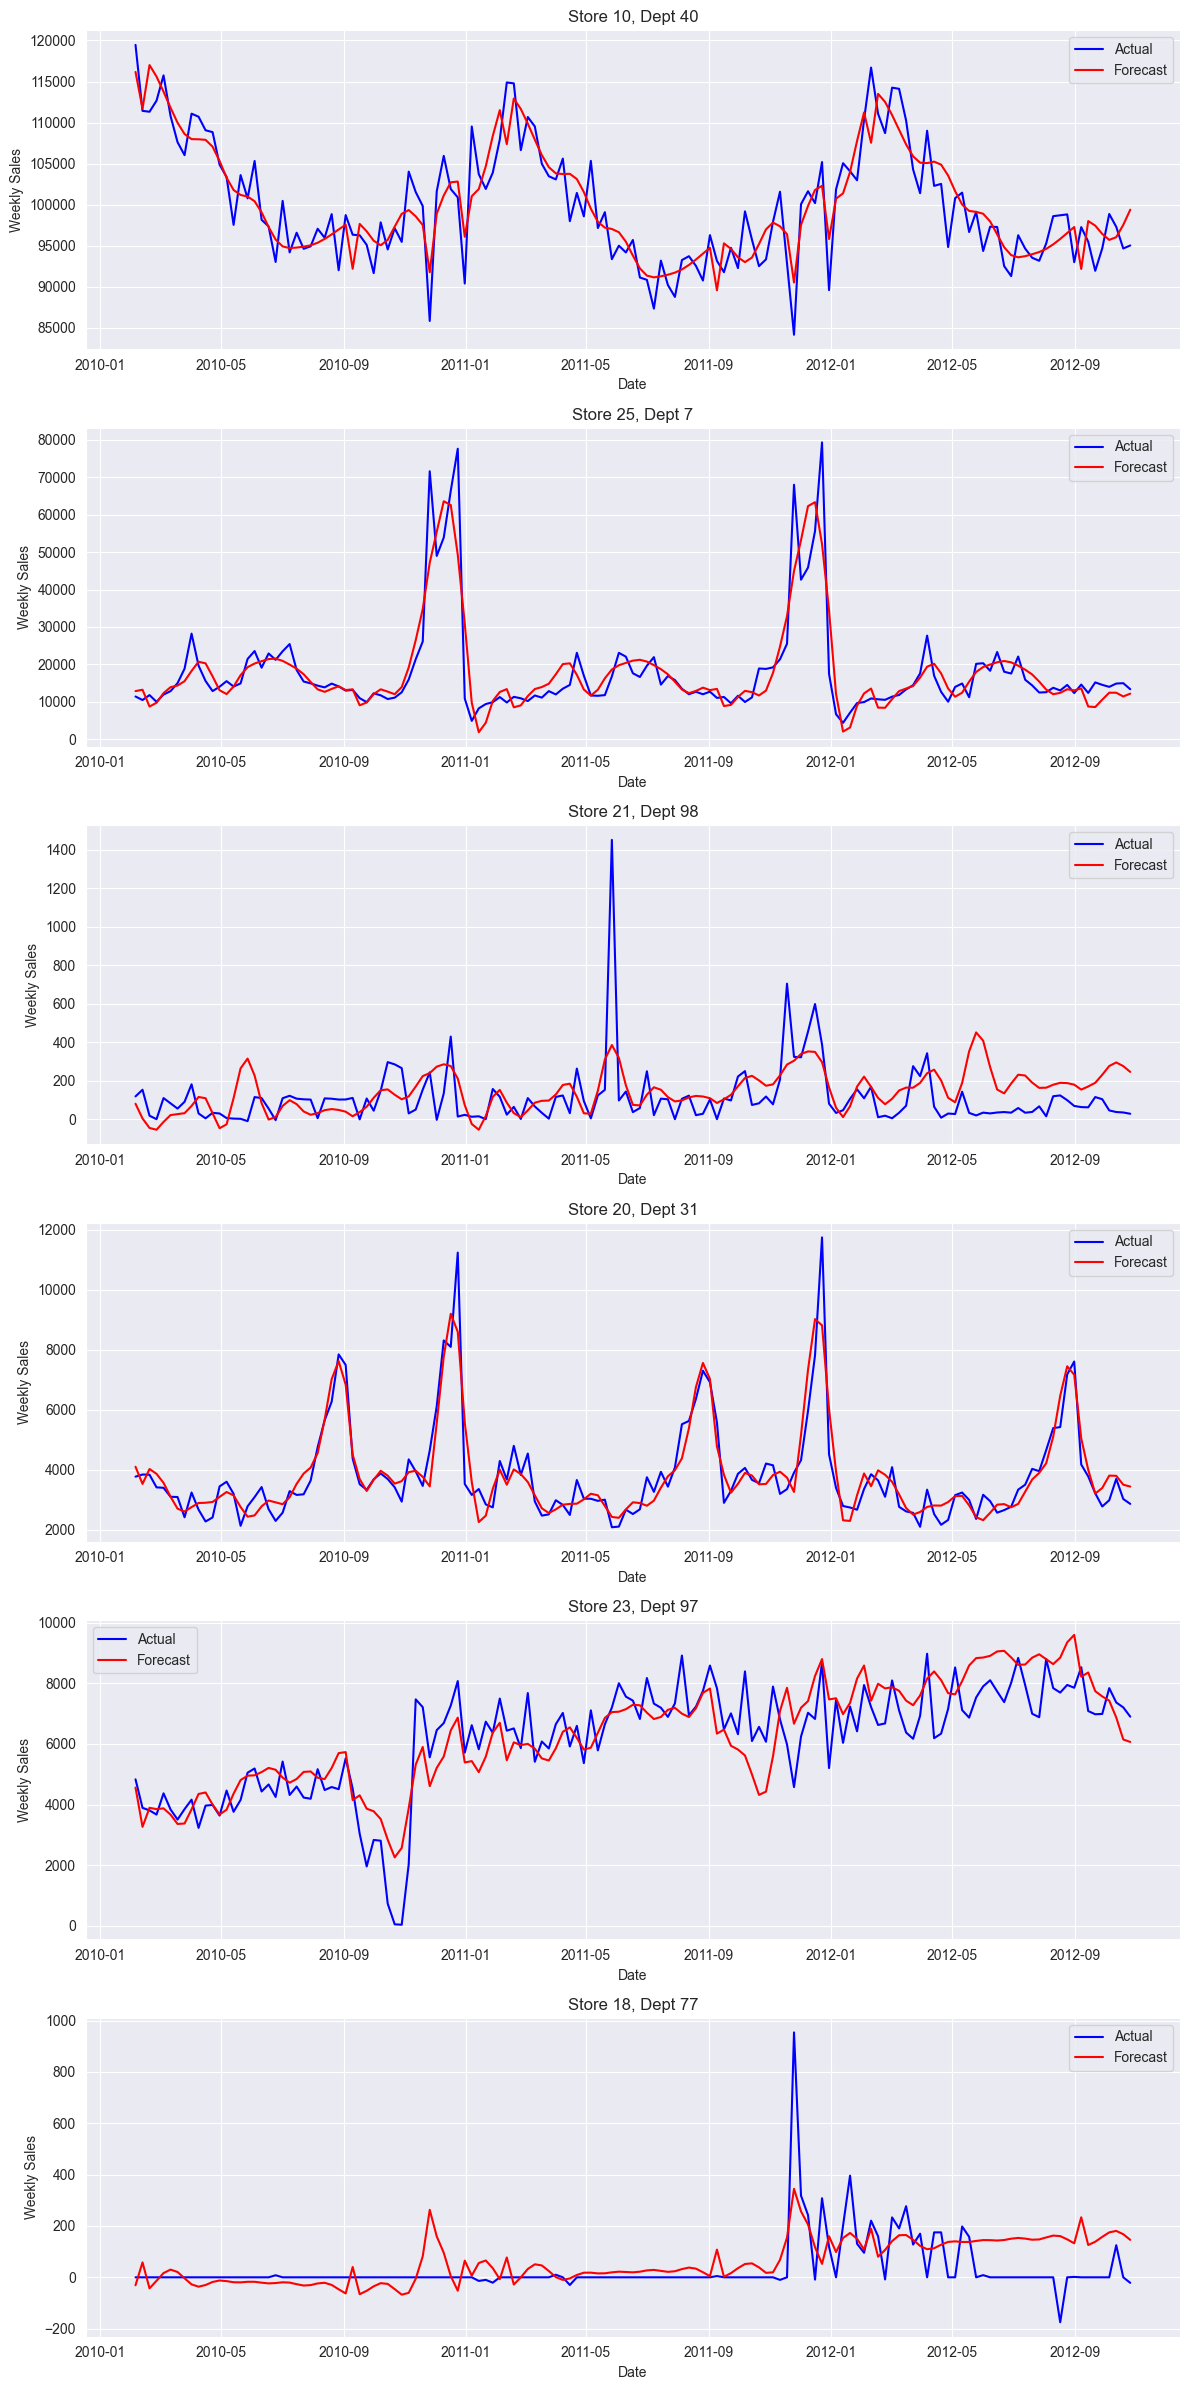

In [240]:
print(len(logged_models))
import matplotlib.pyplot as plt
def plot_logged_models(logged_models, indices_to_plot, transformed_df):
    """
    Plots actual vs predicted sales for selected Prophet models from `logged_models`.

    Args:
        logged_models: list of ((store, dept), model)
        indices_to_plot: list of integer indices (e.g., [1, 2, 3])
        transformed_df: the transformed training DataFrame
        regressor_cols: list of regressor column names used in Prophet
    """
    import matplotlib.pyplot as plt

    num_plots = len(indices_to_plot)
    fig, axes = plt.subplots(nrows=num_plots, figsize=(12, 4 * num_plots))

    if num_plots == 1:
        axes = [axes]

    for i, model_index in enumerate(indices_to_plot):
        (store, dept), model = logged_models[model_index]

        # Get data for this store-dept
        subset = transformed_df[
            (transformed_df["Store"] == store) & (transformed_df["Dept"] == dept)
        ].copy()

        if subset.empty:
            print(f"No data for Store {store}, Dept {dept}. Skipping.")
            continue

        # Prepare data for prediction
        subset = subset.rename(columns={"Date": "ds", "Weekly_Sales": "y"})
        future = subset[["ds"] ]

        # Predict
        forecast = model.predict(future)

        # Plot
        ax = axes[i]
        ax.plot(subset["ds"], subset["y"], label="Actual", color="blue")
        ax.plot(forecast["ds"], forecast["yhat"], label="Forecast", color="red")
        ax.set_title(f"Store {store}, Dept {dept}")
        ax.set_xlabel("Date")
        ax.set_ylabel("Weekly Sales")
        ax.legend()

    plt.tight_layout()
    plt.show()

# Choose indices from logged_models to plot
indices = [1, 2, 3, 5, 80, 210]  # Pick which models to visualize

# Assume these variables are already defined:
# - logged_models
# - transformed_df = full_pipeline.fit_transform(train_df.copy()).sort_values("Date")
# - regressor_cols = [...]  # list of additional regressors like IsHoliday, Temperature, etc.

plot_logged_models(logged_models, indices, transformed_df)


22:35:01 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abnormally. Falling back to Newton.


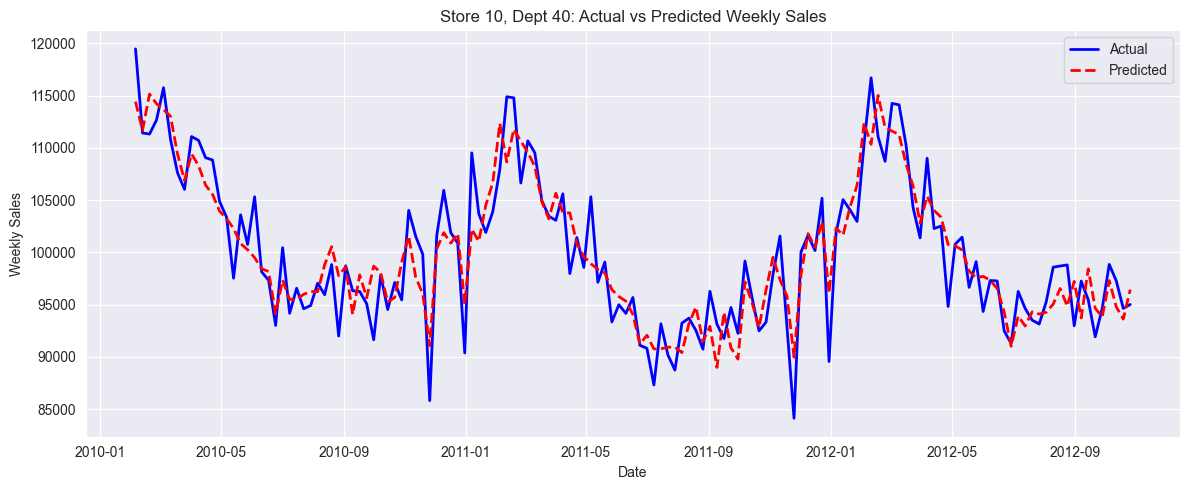

In [206]:
from prophet import Prophet
import matplotlib.pyplot as plt
import pandas as pd

def plot_store_dept_comparison(train_df, store, dept, regressor_cols=None):
    """
    Trains a Prophet model for a given store and department using optional regressors,
    and plots actual (blue) vs predicted (red) weekly sales.

    Parameters:
    - train_df: DataFrame with ['Store', 'Dept', 'Date', 'Weekly_Sales'] and optional features
    - store: int or str
    - dept: int or str
    - regressor_cols: list of str, optional names of additional feature columns
    """
    # Filter data
    df = train_df[(train_df['Store'] == store) & (train_df['Dept'] == dept)].copy()
    if df.empty:
        print(f"⚠️ No data for Store {store}, Dept {dept}")
        return

    # Rename and sort
    df = df.rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
    df = df.sort_values('ds')

    # Initialize Prophet and add regressors
    model = Prophet()
    if regressor_cols:
        for reg in regressor_cols:
            if reg not in df.columns:
                print(f"⚠️ Regressor '{reg}' missing in the data, will fill with 0s.")
                df[reg] = 0
            model.add_regressor(reg)

    # Fit model
    model.fit(df[['ds', 'y'] + (regressor_cols or [])])

    # Forecast on training period (no future for now)
    future = df[['ds'] + regressor_cols].copy()
    # if regressor_cols:
    #     for reg in regressor_cols:
    #         future[reg] = df[reg].values

    forecast = model.predict(future)

    # Plot
    plt.figure(figsize=(12, 5))
    plt.plot(df['ds'], df['y'], label='Actual', color='blue', linewidth=2)
    plt.plot(forecast['ds'], forecast['yhat'], label='Predicted', color='red', linestyle='--', linewidth=2)

    plt.title(f"Store {store}, Dept {dept}: Actual vs Predicted Weekly Sales")
    plt.xlabel("Date")
    plt.ylabel("Weekly Sales")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
regressor_cols = [
    "IsHoliday",
    "HolidayIn1Weeks",
    "HolidayIn2Weeks",
    "HolidayIn3Weeks",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "Size"
]
# Example usage:
plot_store_dept_comparison(transformed_df, store=10, dept=40, regressor_cols=regressor_cols)

# from prophet import Prophet
# import matplotlib.pyplot as plt
# import pandas as pd
# 
# def plot_store_dept_comparison(train_df, store, dept):
#     """
#     Trains a Prophet model for a given store and department,
#     and plots actual (blue) vs predicted (red) weekly sales.
# 
#     Parameters:
#     - train_df: DataFrame with ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']
#     - store: int or str
#     - dept: int or str
#     """
#     # Filter data
#     df = train_df[(train_df['Store'] == store) & (train_df['Dept'] == dept)].copy()
#     if df.empty:
#         print(f"⚠️ No data for Store {store}, Dept {dept}")
#         return
# 
#     # Prepare data for Prophet
#     df = df[['Date', 'Weekly_Sales']].rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
#     df = df.sort_values('ds')
# 
#     # Train model
#     model = Prophet()
#     model.fit(df)
# 
#     # Make future dataframe
#     future = model.make_future_dataframe(periods=0, freq='W')
#     forecast = model.predict(future)
# 
#     # Plot
#     plt.figure(figsize=(12, 5))
#     plt.plot(df['ds'], df['y'], label='Actual', color='blue', linewidth=2)
#     plt.plot(forecast['ds'], forecast['yhat'], label='Predicted', color='red', linestyle='--', linewidth=2)
# 
#     plt.title(f"Store {store}, Dept {dept}: Actual vs Predicted Weekly Sales")
#     plt.xlabel("Date")
#     plt.ylabel("Weekly Sales")
#     plt.legend()
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()
# 
# plot_store_dept_comparison(train_df, store=28, dept=92)


In [160]:
display(train_df.dtypes)

Store                    int64
Dept                     int64
Date            datetime64[ns]
Weekly_Sales           float64
IsHoliday                 bool
dtype: object

## make prediction

In [30]:
from tqdm.notebook import tqdm
import pandas as pd
test_df_ = full_pipeline_test.fit_transform(test_df.copy())

# # Copy and prepare the test set
# test_df_ = test_df.copy()
test_df_['ds'] = pd.to_datetime(test_df_['Date'])  # Prophet requires 'ds'

# Prepare to store all forecasts
predictions = []

if isinstance(logged_models, list):
    logged_models = dict(logged_models)
# Group by each Store-Dept pair
store_dept_groups = test_df_.groupby(['Store', 'Dept'])
display(transformed_df_test)
for (store, dept), group in tqdm(store_dept_groups, desc="Generating predictions"):
    model_key = (store, dept)

    if model_key not in logged_models:
        continue  # Skip or optionally fill with zeros

    model = logged_models[model_key]

    # Ensure we include all the regressors used during training
    future_df = group[['ds']].copy()

    # Add all required regressors
    for reg in regressors:
        # if reg not in group.columns:
        #     print(f"Warning: missing regressor '{reg}' in test group for Store {store}, Dept {dept}")
        #     future_df[reg] = 0  # Fallback to 0 if missing
        # else:
        future_df[reg] = group[reg].values

    # Make forecast
    forecast = model.predict(future_df)

    # Attach metadata
    group_result = group.copy()
    group_result['Weekly_Sales'] = forecast['yhat'].values
    predictions.append(group_result[['Store', 'Dept', 'Date', 'Weekly_Sales']])

# Combine all results
submission_df = pd.concat(predictions)

# Build final Id column for submission
submission_df['Id'] = submission_df['Store'].astype(str) + '_' + \
                      submission_df['Dept'].astype(str) + '_' + \
                      submission_df['Date'].astype(str)

# Final submission format
final_submission = submission_df[['Id', 'Weekly_Sales']].copy()

# Save submission file
final_submission.to_csv("temp/submission_holidays_sharp_regr_2.csv", index=False)
print("✅ Submission file saved as 'submission.csv'")

# from tqdm import tqdm
# import pandas as pd
# 
# # Ensure test_df has the correct format
# test_df_ = test_df.copy()
# test_df_['ds'] = pd.to_datetime(test_df_['Date'])  # Prophet needs this column
# 
# # Prepare list to store results
# predictions = []
# 
# # Go over each Store-Dept pair in the test set
# store_dept_groups = test_df_.groupby(['Store', 'Dept'])
# 
# for (store, dept), group in tqdm(store_dept_groups, desc="Generating predictions"):
#     model_key = (store, dept)
#     
#     if model_key not in models:
#         # You can skip or fill with 0, depending on your strategy
#         continue  # or: group['yhat'] = 0
#     model = models[model_key]
#     
#     # Forecast using only ds (date) column
#     future_df = group[['ds']].copy()
#     forecast = model.predict(future_df)
#     
#     # Extract forecast and attach metadata for submission
#     group_result = group.copy()
#     group_result['Weekly_Sales'] = forecast['yhat'].values
#     predictions.append(group_result[['Store', 'Dept', 'Date', 'Weekly_Sales']])
# 
# # Concatenate all predictions
# submission_df = pd.concat(predictions)
# 
# # Build the required 'Id' column for submission
# submission_df['Id'] = submission_df['Store'].astype(str) + '_' + \
#                       submission_df['Dept'].astype(str) + '_' + \
#                       submission_df['Date'].astype(str)
# 
# # Final format
# final_submission = submission_df[['Id', 'Weekly_Sales']].copy()
# 
# # Save to CSV
# final_submission.to_csv("submission.csv", index=False)
# 
# print("✅ Submission file saved as 'submission.csv'")


,Store,Dept,Date,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,...,IsLaborDay,IsThanksgiving,IsChristmas,month,HolidayIn1Weeks,HolidayIn2Weeks,HolidayIn3Weeks,Type_A,Type_B,Type_C
0,1,1,2012-11-02,0,55.32,3.386,6766.44,5147.70,50.82,3639.90,...,0,0,0,11,0,0,1,1.0,0.0,0.0
1,1,1,2012-11-09,0,61.24,3.314,11421.32,3370.89,40.28,4646.79,...,0,0,0,11,0,1,1,1.0,0.0,0.0
2,1,1,2012-11-16,0,52.92,3.252,9696.28,292.10,103.78,1133.15,...,0,0,0,11,1,1,1,1.0,0.0,0.0
3,1,1,2012-11-23,1,56.23,3.211,883.59,4.17,74910.32,209.91,...,0,1,0,11,0,0,0,1.0,0.0,0.0
4,1,1,2012-11-30,0,52.34,3.207,2460.03,0.00,3838.35,150.57,...,0,0,0,11,0,0,0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115059,45,98,2013-06-28,0,76.05,3.639,4842.29,975.03,3.00,2449.97,...,0,0,0,6,0,0,0,0.0,1.0,0.0
115060,45,98,2013-07-05,0,77.50,3.614,9090.48,2268.58,582.74,5797.47,...,0,0,0,7,0,0,0,0.0,1.0,0.0
115061,45,98,2013-07-12,0,79.37,3.614,3789.94,1827.31,85.72,744.84,...,0,0,0,7,0,0,0,0.0,1.0,0.0
115062,45,98,2013-07-19,0,82.84,3.737,2961.49,1047.07,204.19,363.00,...,0,0,0,7,0,0,0,0.0,1.0,0.0


Generating predictions:   0%|          | 0/3169 [00:00<?, ?it/s]

✅ Submission file saved as 'submission.csv'


In [223]:
final_submission.to_csv("temp/submission_holidays.csv", index=False)